# 💰 Análisis y Visualización del Bot de Trading con LLMs para Bitcoin

## V1: Sistema Original con 4 Modelos

Este notebook analiza **`model_comparison.csv`** con los modelos V1:
- **Llama-3.3-70B** (Meta)
- **Llama-3.1-8B** (Meta)
- **Llama-4-Scout-17B** (Meta)
- **Qwen3-32B** (Alibaba)

### Objetivos:
1. Simular trading para cada LLM
2. Calcular beneficios/pérdidas y Alpha
3. Comparar con estrategia Hold
4. Determinar si las pérdidas son por el mercado o decisiones pobres

## 1️⃣ Cargar Datos y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("[OK] Librerías importadas correctamente")

[OK] Librerías importadas correctamente


In [2]:
# Cargar el CSV de V1
try:
    df = pd.read_csv('model_comparison.csv')
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)
    
    print(f"[OK] Datos cargados exitosamente")
    print(f"\n[INFO] Estadísticas del Dataset:")
    print(f"  Total de registros: {len(df)}")
    print(f"  Período: {df['Timestamp'].min()} a {df['Timestamp'].max()}")
    print(f"  Ciclos: {df['Cycle'].nunique()}")
    print(f"  Modelos: {df['Model_Name'].nunique()}")
    print(f"\n[MODELS] Modelos en V1:")
    for model in df['Model_Name'].unique():
        count = len(df[df['Model_Name'] == model])
        print(f"  - {model}: {count} registros")
    
    print(f"\n[DATA] Primeras filas:")
    display(df.head(8))
    
except FileNotFoundError:
    print("[ERROR] Archivo 'model_comparison.csv' no encontrado")
    print("Por favor, ejecuta primero: python model_comparison.py")
except Exception as e:
    print(f"[ERROR] {e}")

[OK] Datos cargados exitosamente

[INFO] Estadísticas del Dataset:
  Total de registros: 14128
  Período: 2025-10-13 14:03:26 a 2025-10-26 20:28:45
  Ciclos: 2926
  Modelos: 4

[MODELS] Modelos en V1:
  - Llama-3.3-70B: 3532 registros
  - Llama-3.1-8B: 3532 registros
  - Llama-4-Scout-17B: 3532 registros
  - Qwen3-32B: 3532 registros

[DATA] Primeras filas:


,Timestamp,Cycle,Symbol,Price,RSI,MACD_Signal,Trend,Model_Name,Model_Signal,Model_Response_Time_ms,Consensus_Signal,Agreement_Level
0,2025-10-13 14:03:26,1,BTCUSDT,114003.98,36.31,BEARISH,BEARISH/BEARISH,Llama-3.3-70B,SELL,0,SELL,75.0
1,2025-10-13 14:03:26,1,BTCUSDT,114003.98,36.31,BEARISH,BEARISH/BEARISH,Llama-3.1-8B,SELL,0,SELL,75.0
2,2025-10-13 14:03:26,1,BTCUSDT,114003.98,36.31,BEARISH,BEARISH/BEARISH,Llama-4-Scout-17B,SELL,0,SELL,75.0
3,2025-10-13 14:03:26,1,BTCUSDT,114003.98,36.31,BEARISH,BEARISH/BEARISH,Qwen3-32B,HOLD,0,SELL,75.0
4,2025-10-13 14:08:28,2,BTCUSDT,114165.37,41.59,BEARISH,BEARISH/BEARISH,Llama-3.3-70B,SELL,0,SELL,75.0
5,2025-10-13 14:08:28,2,BTCUSDT,114165.37,41.59,BEARISH,BEARISH/BEARISH,Llama-3.1-8B,SELL,0,SELL,75.0
6,2025-10-13 14:08:28,2,BTCUSDT,114165.37,41.59,BEARISH,BEARISH/BEARISH,Llama-4-Scout-17B,SELL,0,SELL,75.0
7,2025-10-13 14:08:28,2,BTCUSDT,114165.37,41.59,BEARISH,BEARISH/BEARISH,Qwen3-32B,HOLD,0,SELL,75.0


## 2️⃣ Simulación de Trading por LLM

### Estrategia de Simulación:
- **Capital Inicial**: 10,000 USDT
- **BUY**: Comprar todo el cash disponible en BTC
- **SELL**: Vender todo el BTC a USDT
- **HOLD**: Mantener posición actual
- **ERROR**: Tratado como HOLD

In [3]:
def simulate_trading(model_df, initial_cash=10000):
    """
    Simula trading siguiendo las señales del modelo.
    Retorna DataFrame con timestamp y valor del portafolio.
    """
    model_df = model_df.sort_values('Timestamp').reset_index(drop=True)
    cash = initial_cash
    btc = 0
    values = []
    
    for idx, row in model_df.iterrows():
        price = row['Price']
        signal = str(row['Model_Signal']).upper()
        
        # Ejecutar señal
        if signal == 'BUY' and cash > 0:
            btc = cash / price
            cash = 0
        elif signal == 'SELL' and btc > 0:
            cash = btc * price
            btc = 0
        # HOLD o ERROR: no hacer nada
        
        # Calcular valor actual
        current_value = cash + (btc * price)
        values.append({
            'Timestamp': row['Timestamp'],
            'Value': current_value,
            'Cash': cash,
            'BTC': btc,
            'Price': price
        })
    
    return pd.DataFrame(values)

# Simular para cada modelo
print("[INFO] Simulando trading para cada modelo...\n")
models = df['Model_Name'].unique()
sim_dfs = {}

for model in models:
    model_df = df[df['Model_Name'] == model]
    sim_dfs[model] = simulate_trading(model_df)
    
    final_value = sim_dfs[model]['Value'].iloc[-1]
    profit = final_value - 10000
    roi = (profit / 10000) * 100
    
    emoji = "[+]" if profit > 0 else "[-]" if profit < 0 else "[=]"
    print(f"{emoji} {model}:")
    print(f"    Capital Final: ${final_value:,.2f}")
    print(f"    Beneficio: ${profit:,.2f}")
    print(f"    ROI: {roi:.2f}%\n")

print("[OK] Simulación completada")

[INFO] Simulando trading para cada modelo...

[+] Llama-3.3-70B:
    Capital Final: $10,166.24
    Beneficio: $166.24
    ROI: 1.66%

[-] Llama-3.1-8B:
    Capital Final: $9,793.41
    Beneficio: $-206.59
    ROI: -2.07%

[-] Llama-4-Scout-17B:
    Capital Final: $9,729.48
    Beneficio: $-270.52
    ROI: -2.71%

[-] Llama-4-Scout-17B:
    Capital Final: $9,729.48
    Beneficio: $-270.52
    ROI: -2.71%

[+] Qwen3-32B:
    Capital Final: $10,692.05
    Beneficio: $692.05
    ROI: 6.92%

[OK] Simulación completada
[+] Qwen3-32B:
    Capital Final: $10,692.05
    Beneficio: $692.05
    ROI: 6.92%

[OK] Simulación completada


## 3️⃣ Visualización: Progresión del Valor del Portafolio

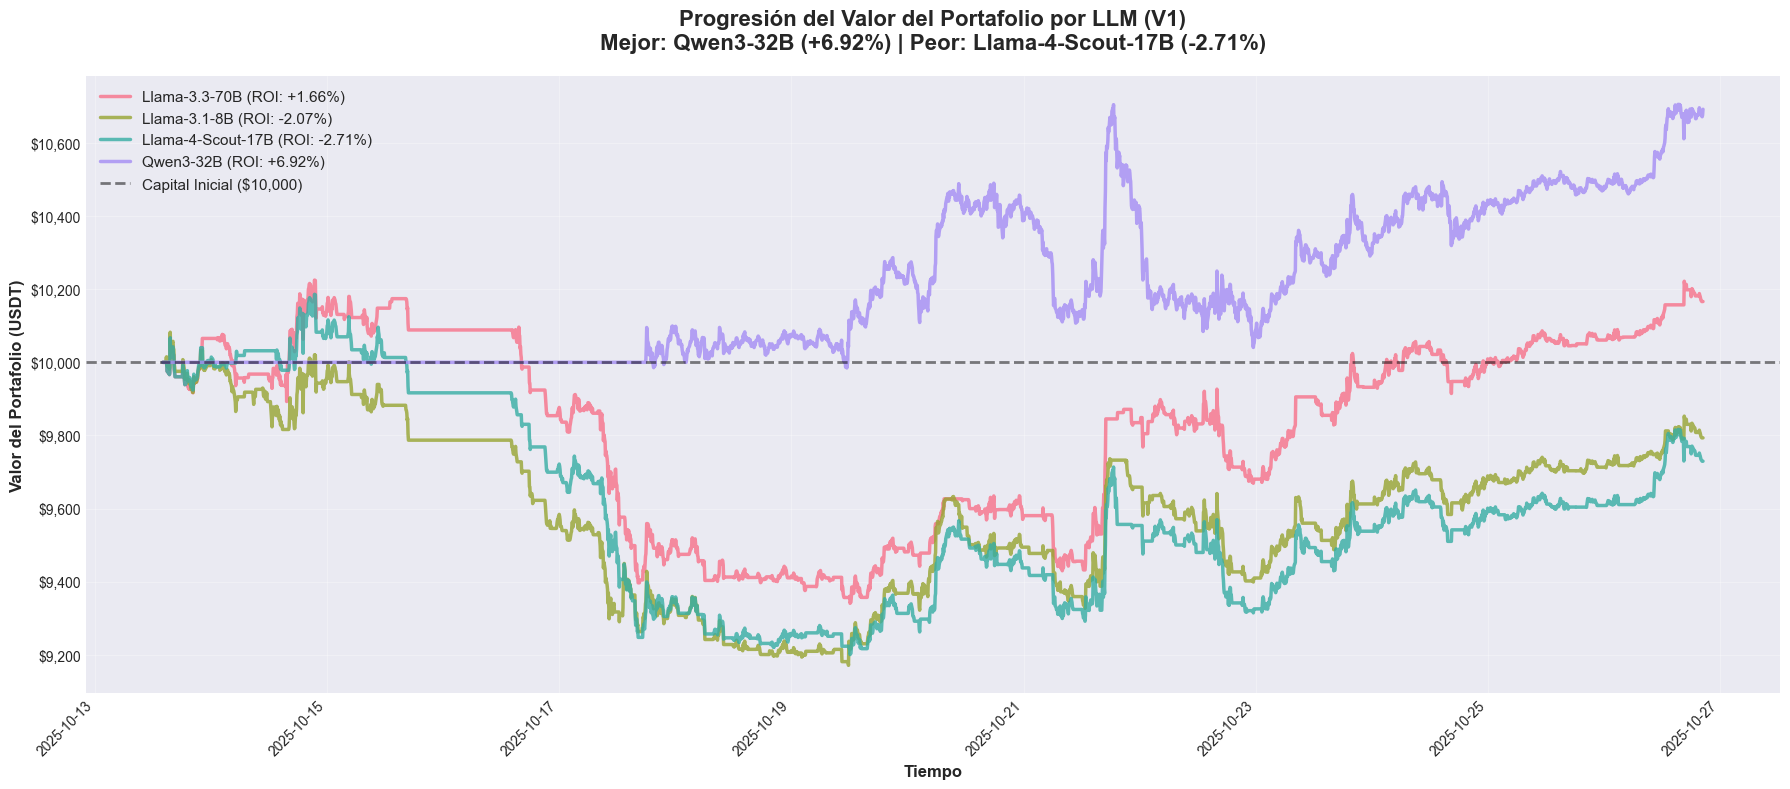

In [4]:
plt.figure(figsize=(18, 8))
colors = sns.color_palette('husl', len(models))

for i, (model, sim_df) in enumerate(sim_dfs.items()):
    final_value = sim_df['Value'].iloc[-1]
    roi = ((final_value - 10000) / 10000) * 100
    plt.plot(sim_df['Timestamp'], sim_df['Value'], 
             label=f"{model} (ROI: {roi:+.2f}%)",
             color=colors[i], linewidth=2.5, alpha=0.8)

# Línea de capital inicial
plt.axhline(y=10000, color='black', linestyle='--', linewidth=2, 
            alpha=0.5, label='Capital Inicial ($10,000)')

# Identificar mejor y peor
final_values = {model: sim_df['Value'].iloc[-1] for model, sim_df in sim_dfs.items()}
best_model = max(final_values, key=final_values.get)
worst_model = min(final_values, key=final_values.get)
best_roi = ((final_values[best_model] - 10000) / 10000) * 100
worst_roi = ((final_values[worst_model] - 10000) / 10000) * 100

plt.title(f'Progresión del Valor del Portafolio por LLM (V1)\n' +
          f'Mejor: {best_model} ({best_roi:+.2f}%) | Peor: {worst_model} ({worst_roi:+.2f}%)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
plt.ylabel('Valor del Portafolio (USDT)', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Formato del eje Y
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

## 4️⃣ Visualización: Precio de Bitcoin a lo Largo del Tiempo

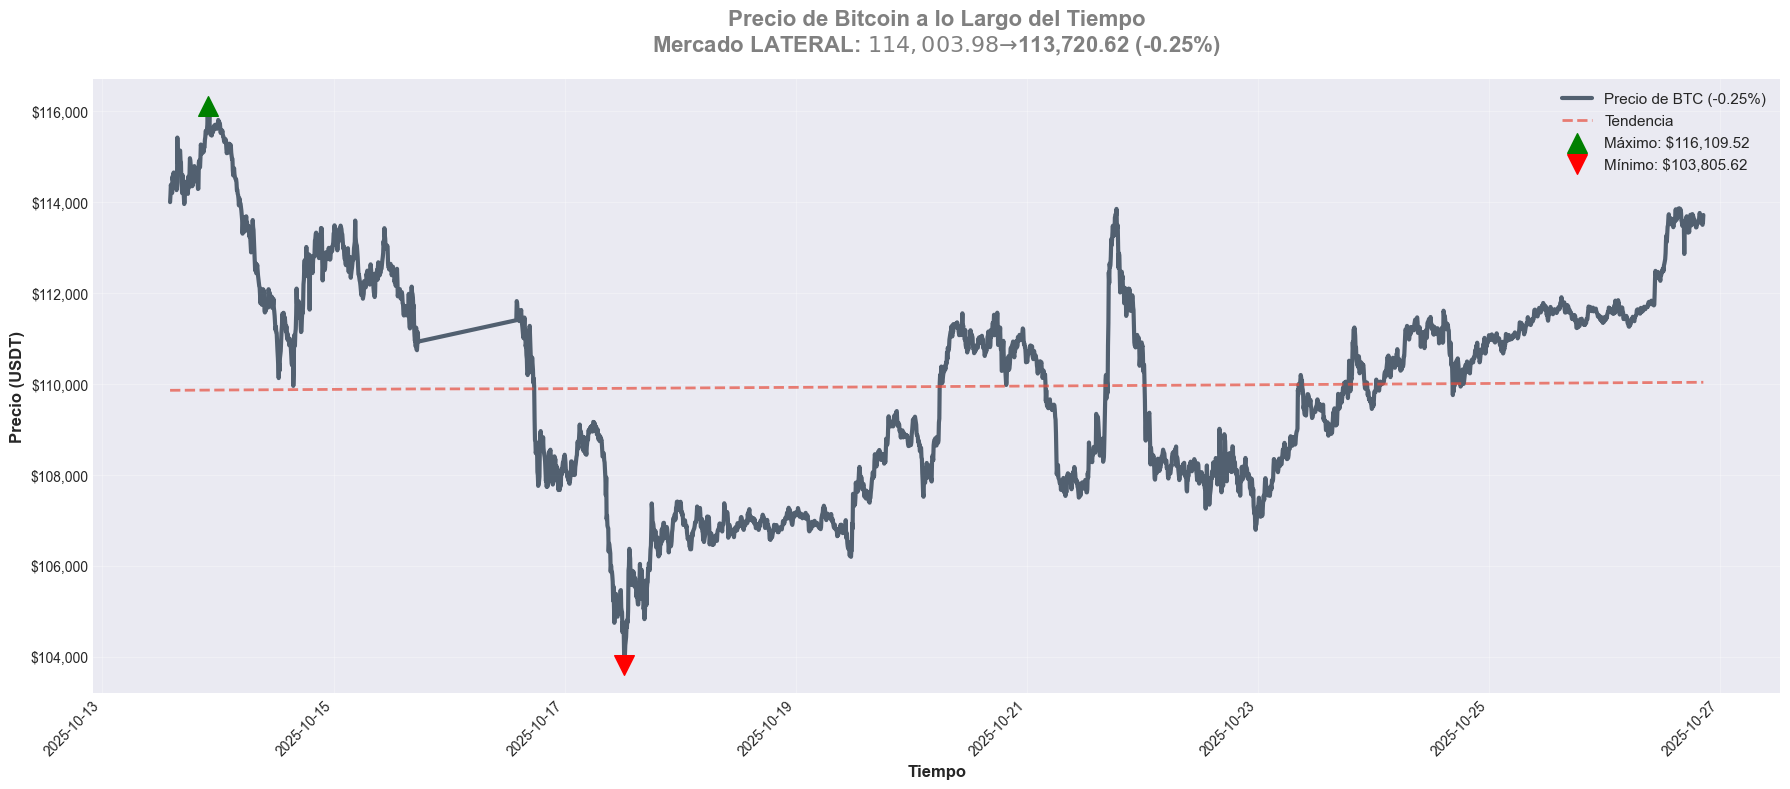


[ANÁLISIS] Movimiento del Precio:
  Precio Inicial: $114,003.98
  Precio Final: $113,720.62
  Cambio: -0.25%
  Tipo de Mercado: LATERAL
  Máximo: $116,109.52
  Mínimo: $103,805.62
  Volatilidad: 11.85%


In [5]:
# Obtener precio único por timestamp
price_df = df[['Timestamp', 'Price']].drop_duplicates().sort_values('Timestamp')

# Calcular cambio total
if not price_df.empty:
    initial_price = price_df['Price'].iloc[0]
    final_price = price_df['Price'].iloc[-1]
    price_change = ((final_price - initial_price) / initial_price) * 100
    
    plt.figure(figsize=(18, 8))
    plt.plot(price_df['Timestamp'], price_df['Price'], 
             label=f'Precio de BTC ({price_change:+.2f}%)', 
             color='#2c3e50', linewidth=3, alpha=0.8)
    
    # Línea de tendencia
    z = np.polyfit(range(len(price_df)), price_df['Price'], 1)
    p = np.poly1d(z)
    plt.plot(price_df['Timestamp'], p(range(len(price_df))), 
             "--", color='#e74c3c', linewidth=2, alpha=0.7, label='Tendencia')
    
    # Marcadores de máximo y mínimo
    max_price = price_df['Price'].max()
    min_price = price_df['Price'].min()
    max_time = price_df[price_df['Price'] == max_price]['Timestamp'].iloc[0]
    min_time = price_df[price_df['Price'] == min_price]['Timestamp'].iloc[0]
    
    plt.scatter([max_time], [max_price], color='green', s=200, 
                marker='^', zorder=5, label=f'Máximo: ${max_price:,.2f}')
    plt.scatter([min_time], [min_price], color='red', s=200, 
                marker='v', zorder=5, label=f'Mínimo: ${min_price:,.2f}')
    
    market_type = "BAJISTA" if price_change < -2 else "ALCISTA" if price_change > 2 else "LATERAL"
    market_color = "red" if price_change < -2 else "green" if price_change > 2 else "gray"
    
    plt.title(f'Precio de Bitcoin a lo Largo del Tiempo\n' +
              f'Mercado {market_type}: ${initial_price:,.2f} → ${final_price:,.2f} ({price_change:+.2f}%)',
              fontsize=16, fontweight='bold', pad=20, color=market_color)
    plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
    plt.ylabel('Precio (USDT)', fontsize=12, fontweight='bold')
    plt.legend(loc='best', fontsize=11, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    
    # Formato del eje Y
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    plt.tight_layout()
    plt.show()
    
    # Análisis
    print(f"\n[ANÁLISIS] Movimiento del Precio:")
    print(f"  Precio Inicial: ${initial_price:,.2f}")
    print(f"  Precio Final: ${final_price:,.2f}")
    print(f"  Cambio: {price_change:+.2f}%")
    print(f"  Tipo de Mercado: {market_type}")
    print(f"  Máximo: ${max_price:,.2f}")
    print(f"  Mínimo: ${min_price:,.2f}")
    print(f"  Volatilidad: {((max_price - min_price) / min_price * 100):.2f}%")

## 5️⃣ Comparación con Estrategia Hold

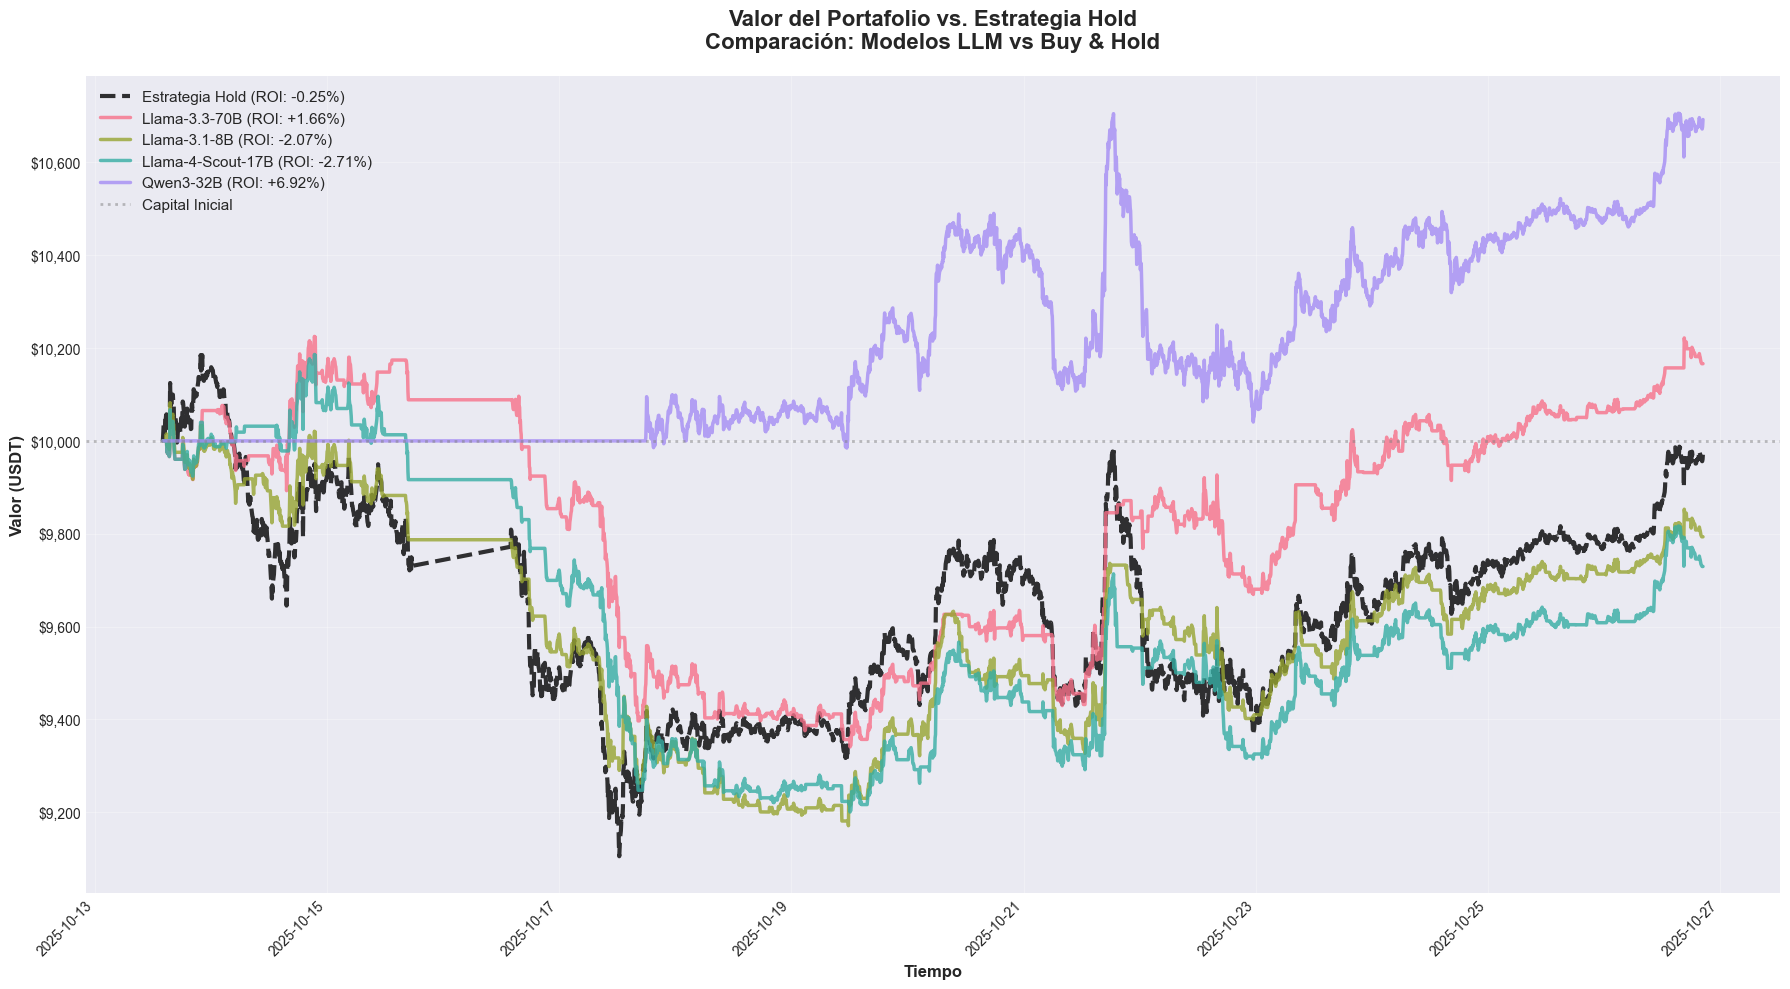


[COMPARACIÓN] Modelos vs Hold:
  Hold ROI: -0.25%

  [+] Llama-3.3-70B: +1.66% (MEJOR que Hold: +1.91pp)
  [-] Llama-3.1-8B: -2.07% (PEOR que Hold: -1.82pp)
  [-] Llama-4-Scout-17B: -2.71% (PEOR que Hold: -2.46pp)
  [+] Qwen3-32B: +6.92% (MEJOR que Hold: +7.17pp)


In [6]:
if not price_df.empty:
    initial_price = price_df['Price'].iloc[0]
    hold_values = (price_df['Price'] / initial_price) * 10000
    
    plt.figure(figsize=(18, 10))
    
    # Estrategia Hold
    hold_final = hold_values.iloc[-1]
    hold_roi = ((hold_final - 10000) / 10000) * 100
    plt.plot(price_df['Timestamp'], hold_values, 
             label=f'Estrategia Hold (ROI: {hold_roi:+.2f}%)', 
             color='black', linestyle='--', linewidth=3, alpha=0.8)
    
    # Modelos LLM
    for i, (model, sim_df) in enumerate(sim_dfs.items()):
        final_value = sim_df['Value'].iloc[-1]
        roi = ((final_value - 10000) / 10000) * 100
        plt.plot(sim_df['Timestamp'], sim_df['Value'], 
                 label=f"{model} (ROI: {roi:+.2f}%)",
                 color=colors[i], linewidth=2.5, alpha=0.8)
    
    # Línea base
    plt.axhline(y=10000, color='gray', linestyle=':', linewidth=2, 
                alpha=0.5, label='Capital Inicial')
    
    plt.title('Valor del Portafolio vs. Estrategia Hold\n' +
              'Comparación: Modelos LLM vs Buy & Hold',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Tiempo', fontsize=12, fontweight='bold')
    plt.ylabel('Valor (USDT)', fontsize=12, fontweight='bold')
    plt.legend(loc='best', fontsize=11, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    
    # Formato del eje Y
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    plt.tight_layout()
    plt.show()
    
    # Comparación con Hold
    print(f"\n[COMPARACIÓN] Modelos vs Hold:")
    print(f"  Hold ROI: {hold_roi:+.2f}%\n")
    for model, sim_df in sim_dfs.items():
        final_value = sim_df['Value'].iloc[-1]
        roi = ((final_value - 10000) / 10000) * 100
        diff = roi - hold_roi
        status = "MEJOR" if diff > 0 else "PEOR" if diff < 0 else "IGUAL"
        emoji = "[+]" if diff > 0 else "[-]" if diff < 0 else "[=]"
        print(f"  {emoji} {model}: {roi:+.2f}% ({status} que Hold: {diff:+.2f}pp)")

## 6️⃣ Beneficios/Pérdidas Finales por LLM

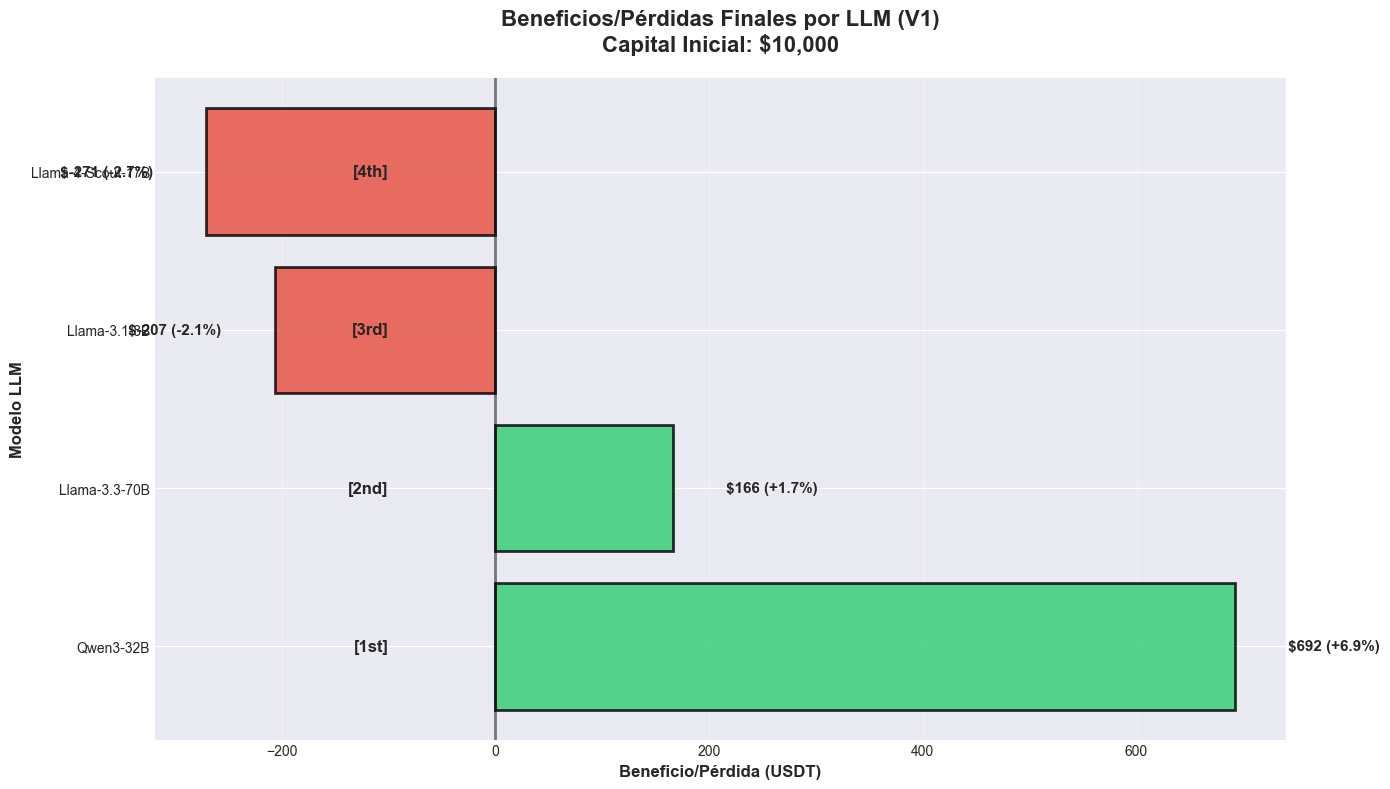


[RANKING] Beneficios/Pérdidas Finales:
[1st] Qwen3-32B: $+692.05 (+6.92%)
[2nd] Llama-3.3-70B: $+166.24 (+1.66%)
[3rd] Llama-3.1-8B: $-206.59 (-2.07%)
[4th] Llama-4-Scout-17B: $-270.52 (-2.71%)


In [7]:
finals = {model: sim_df['Value'].iloc[-1] - 10000 for model, sim_df in sim_dfs.items()}
final_df = pd.DataFrame.from_dict(finals, orient='index', columns=['Profit/Loss'])
final_df = final_df.sort_values('Profit/Loss', ascending=False)

plt.figure(figsize=(14, 8))
colors_bar = ['#2ecc71' if x > 0 else '#e74c3c' if x < 0 else '#95a5a6' 
              for x in final_df['Profit/Loss']]

bars = plt.barh(final_df.index, final_df['Profit/Loss'], 
                color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)

# Valores en las barras
for i, (bar, val) in enumerate(zip(bars, final_df['Profit/Loss'])):
    roi = (val / 10000) * 100
    x_pos = val + 50 if val > 0 else val - 50
    ha = 'left' if val > 0 else 'right'
    plt.text(x_pos, bar.get_y() + bar.get_height()/2., 
             f'${val:,.0f} ({roi:+.1f}%)', 
             ha=ha, va='center', fontweight='bold', fontsize=11)
    
    # Emoji de ranking
    emoji = "[1st]" if i == 0 else "[2nd]" if i == 1 else "[3rd]" if i == 2 else "[4th]"
    plt.text(-100, bar.get_y() + bar.get_height()/2., emoji, 
             ha='right', va='center', fontsize=12, fontweight='bold')

# Línea en cero
plt.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.5)

plt.title('Beneficios/Pérdidas Finales por LLM (V1)\n' +
          f'Capital Inicial: $10,000',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Beneficio/Pérdida (USDT)', fontsize=12, fontweight='bold')
plt.ylabel('Modelo LLM', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n[RANKING] Beneficios/Pérdidas Finales:")
print("="*70)
sorted_finals = sorted(finals.items(), key=lambda x: x[1], reverse=True)
for i, (model, profit) in enumerate(sorted_finals, 1):
    roi = (profit / 10000) * 100
    emoji = "[1st]" if i == 1 else "[2nd]" if i == 2 else "[3rd]" if i == 3 else "[4th]"
    print(f"{emoji} {model}: ${profit:+,.2f} ({roi:+.2f}%)")

## 7️⃣ Tiempos de Respuesta por LLM

In [8]:
# Nota: V1 tiene tiempos en 0 porque se guardaron después
if df['Model_Response_Time_ms'].sum() > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Boxplot
    sns.boxplot(x='Model_Name', y='Model_Response_Time_ms', data=df, 
                palette='husl', ax=ax1)
    ax1.set_title('Distribución de Tiempos de Respuesta', 
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Modelo LLM', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Tiempo de Respuesta (ms)', fontsize=11, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Barras con promedio
    response_stats = df.groupby('Model_Name')['Model_Response_Time_ms'].agg(['mean', 'std'])
    response_stats = response_stats.sort_values('mean')
    
    x_pos = np.arange(len(response_stats))
    bars = ax2.bar(x_pos, response_stats['mean'], yerr=response_stats['std'],
                   capsize=5, alpha=0.8, color=colors, edgecolor='black', linewidth=1.5)
    
    ax2.set_title('Tiempo Promedio de Respuesta', 
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Modelo LLM', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Tiempo Promedio (ms)', fontsize=11, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(response_stats.index, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] Los tiempos de respuesta no están disponibles en V1")

[INFO] Los tiempos de respuesta no están disponibles en V1


## 🔬 Análisis de ALPHA: Beneficio Ajustado al Mercado

El **ALPHA** mide la habilidad del modelo **independientemente** del movimiento del mercado:

**Alpha = ROI_modelo - ROI_mercado**

- **Alpha > 0**: El modelo **AÑADE valor** (mejor que Buy & Hold)
- **Alpha = 0**: El modelo **igual** al mercado
- **Alpha < 0**: El modelo **DESTRUYE valor** (peor que Buy & Hold)


[ALPHA] Análisis de Beneficio Ajustado al Mercado
Alpha = ROI_modelo - ROI_mercado
(Mide habilidad del modelo independiente del mercado)

[+] Llama-3.3-70B:
    ROI Modelo: +1.66%
    ROI Mercado (Hold): -0.25%
    Alpha: +1.91pp
    CONCLUSIÓN: Modelo AÑADE valor (+1.91pp) ✓

[-] Llama-3.1-8B:
    ROI Modelo: -2.07%
    ROI Mercado (Hold): -0.25%
    Alpha: -1.82pp
    CONCLUSIÓN: Modelo DESTRUYE valor (-1.82pp) ✗

[-] Llama-4-Scout-17B:
    ROI Modelo: -2.71%
    ROI Mercado (Hold): -0.25%
    Alpha: -2.46pp
    CONCLUSIÓN: Modelo DESTRUYE valor (-2.46pp) ✗

[+] Qwen3-32B:
    ROI Modelo: +6.92%
    ROI Mercado (Hold): -0.25%
    Alpha: +7.17pp
    CONCLUSIÓN: Modelo AÑADE valor (+7.17pp) ✓



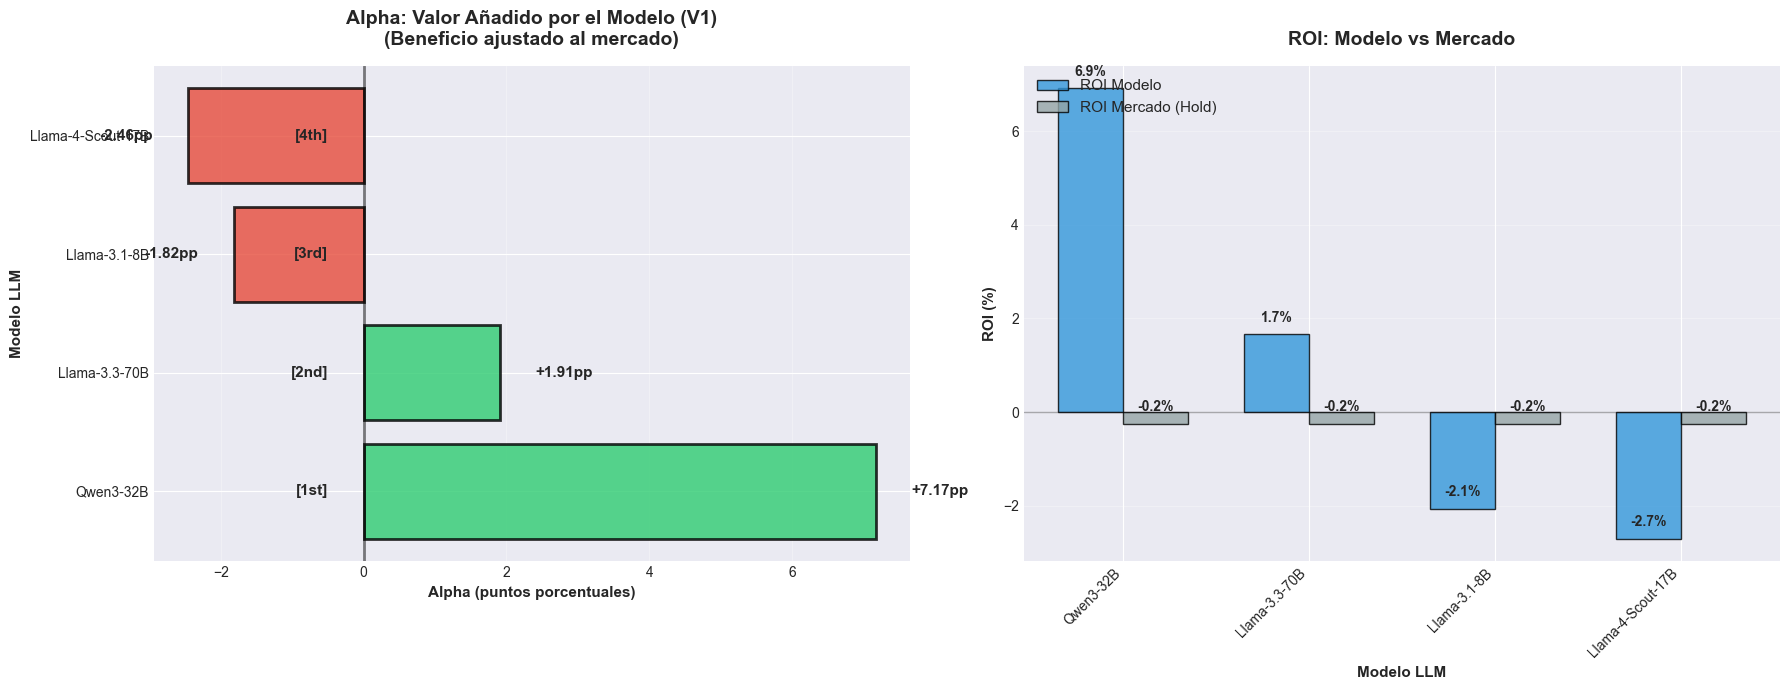


[MEJOR ALPHA]: Qwen3-32B
  Alpha: +7.17pp
  Interpretación: Qwen3-32B supera al mercado en 7.17 puntos porcentuales

[MODELOS CON VALOR AÑADIDO]: 2/4
  ✓ Llama-3.3-70B: +1.91pp
  ✓ Qwen3-32B: +7.17pp


In [9]:
# Calcular Alpha para cada modelo
print("\n[ALPHA] Análisis de Beneficio Ajustado al Mercado")
print("="*80)
print(f"Alpha = ROI_modelo - ROI_mercado")
print(f"(Mide habilidad del modelo independiente del mercado)\n")

# Calcular Hold ROI
if not price_df.empty:
    hold_final = hold_values.iloc[-1]
    hold_roi = ((hold_final - 10000) / 10000) * 100
    
    # Crear DataFrame para visualización
    alpha_data = []
    
    for model, sim_df in sim_dfs.items():
        final_value = sim_df['Value'].iloc[-1]
        roi = ((final_value - 10000) / 10000) * 100
        alpha = roi - hold_roi
        
        alpha_data.append({
            'Model': model,
            'ROI_Model': roi,
            'ROI_Market': hold_roi,
            'Alpha': alpha
        })
        
        emoji = "[+]" if alpha > 0 else "[-]" if alpha < 0 else "[=]"
        print(f"{emoji} {model}:")
        print(f"    ROI Modelo: {roi:+.2f}%")
        print(f"    ROI Mercado (Hold): {hold_roi:+.2f}%")
        print(f"    Alpha: {alpha:+.2f}pp")
        
        if alpha > 0:
            print(f"    CONCLUSIÓN: Modelo AÑADE valor (+{alpha:.2f}pp) ✓")
        elif alpha < -0.5:
            print(f"    CONCLUSIÓN: Modelo DESTRUYE valor ({alpha:.2f}pp) ✗")
        else:
            print(f"    CONCLUSIÓN: Modelo similar al mercado")
        print()
    
    alpha_df = pd.DataFrame(alpha_data)
    
    # Visualización de Alpha
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Gráfico 1: Barras de Alpha
    alpha_df_sorted = alpha_df.sort_values('Alpha', ascending=False)
    colors_alpha = ['#2ecc71' if x > 0 else '#e74c3c' if x < -0.5 else '#95a5a6' 
                    for x in alpha_df_sorted['Alpha']]
    
    bars = ax1.barh(alpha_df_sorted['Model'], alpha_df_sorted['Alpha'], 
                    color=colors_alpha, alpha=0.8, edgecolor='black', linewidth=2)
    
    # Valores en las barras
    for i, (bar, val) in enumerate(zip(bars, alpha_df_sorted['Alpha'])):
        x_pos = val + 0.5 if val > 0 else val - 0.5
        ha = 'left' if val > 0 else 'right'
        ax1.text(x_pos, bar.get_y() + bar.get_height()/2., 
                 f'{val:+.2f}pp', 
                 ha=ha, va='center', fontweight='bold', fontsize=11)
        
        # Ranking
        emoji = "[1st]" if i == 0 else "[2nd]" if i == 1 else "[3rd]" if i == 2 else "[4th]"
        ax1.text(-0.5, bar.get_y() + bar.get_height()/2., emoji, 
                 ha='right', va='center', fontsize=11, fontweight='bold')
    
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.5)
    ax1.set_title('Alpha: Valor Añadido por el Modelo (V1)\n(Beneficio ajustado al mercado)', 
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Alpha (puntos porcentuales)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Modelo LLM', fontsize=11, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Gráfico 2: Comparación ROI vs Market
    x_pos = np.arange(len(alpha_df_sorted))
    width = 0.35
    
    bars1 = ax2.bar(x_pos - width/2, alpha_df_sorted['ROI_Model'], width,
                    label='ROI Modelo', color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = ax2.bar(x_pos + width/2, alpha_df_sorted['ROI_Market'], width,
                    label='ROI Mercado (Hold)', color='#95a5a6', alpha=0.8, edgecolor='black')
    
    # Valores en las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                     f'{height:.1f}%',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_title('ROI: Modelo vs Mercado', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Modelo LLM', fontsize=11, fontweight='bold')
    ax2.set_ylabel('ROI (%)', fontsize=11, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(alpha_df_sorted['Model'], rotation=45, ha='right')
    ax2.legend(fontsize=11, loc='upper left')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Resumen
    best_alpha = alpha_df_sorted.iloc[0]
    print(f"\n[MEJOR ALPHA]: {best_alpha['Model']}")
    print(f"  Alpha: {best_alpha['Alpha']:+.2f}pp")
    print(f"  Interpretación: {best_alpha['Model']} supera al mercado en {best_alpha['Alpha']:.2f} puntos porcentuales")
    
    models_with_positive_alpha = alpha_df[alpha_df['Alpha'] > 0]
    if len(models_with_positive_alpha) > 0:
        print(f"\n[MODELOS CON VALOR AÑADIDO]: {len(models_with_positive_alpha)}/{len(alpha_df)}")
        for _, row in models_with_positive_alpha.iterrows():
            print(f"  ✓ {row['Model']}: +{row['Alpha']:.2f}pp")
    else:
        print(f"\n[ADVERTENCIA]: Ningún modelo supera al mercado")
        print(f"  Recomendación: Usar estrategia Buy & Hold simple")
    
else:
    print("[ERROR] No hay datos de precio disponibles")

## 📈 Análisis de Distribución de Señales


[ANÁLISIS] Distribución de Señales por Modelo

Llama-3.3-70B:
  Total señales: 3532
    BUY: 988 (28.0%)
    SELL: 696 (19.7%)
    HOLD: 1848 (52.3%)

Llama-3.1-8B:
  Total señales: 3532
    BUY: 1230 (34.8%)
    SELL: 801 (22.7%)
    HOLD: 1501 (42.5%)

Llama-4-Scout-17B:
  Total señales: 3532
    BUY: 958 (27.1%)
    SELL: 706 (20.0%)
    HOLD: 1859 (52.6%)
    ERROR: 9 (0.3%)

Qwen3-32B:
  Total señales: 3532
    BUY: 5 (0.1%)
    HOLD: 3526 (99.8%)
    ERROR: 1 (0.0%)


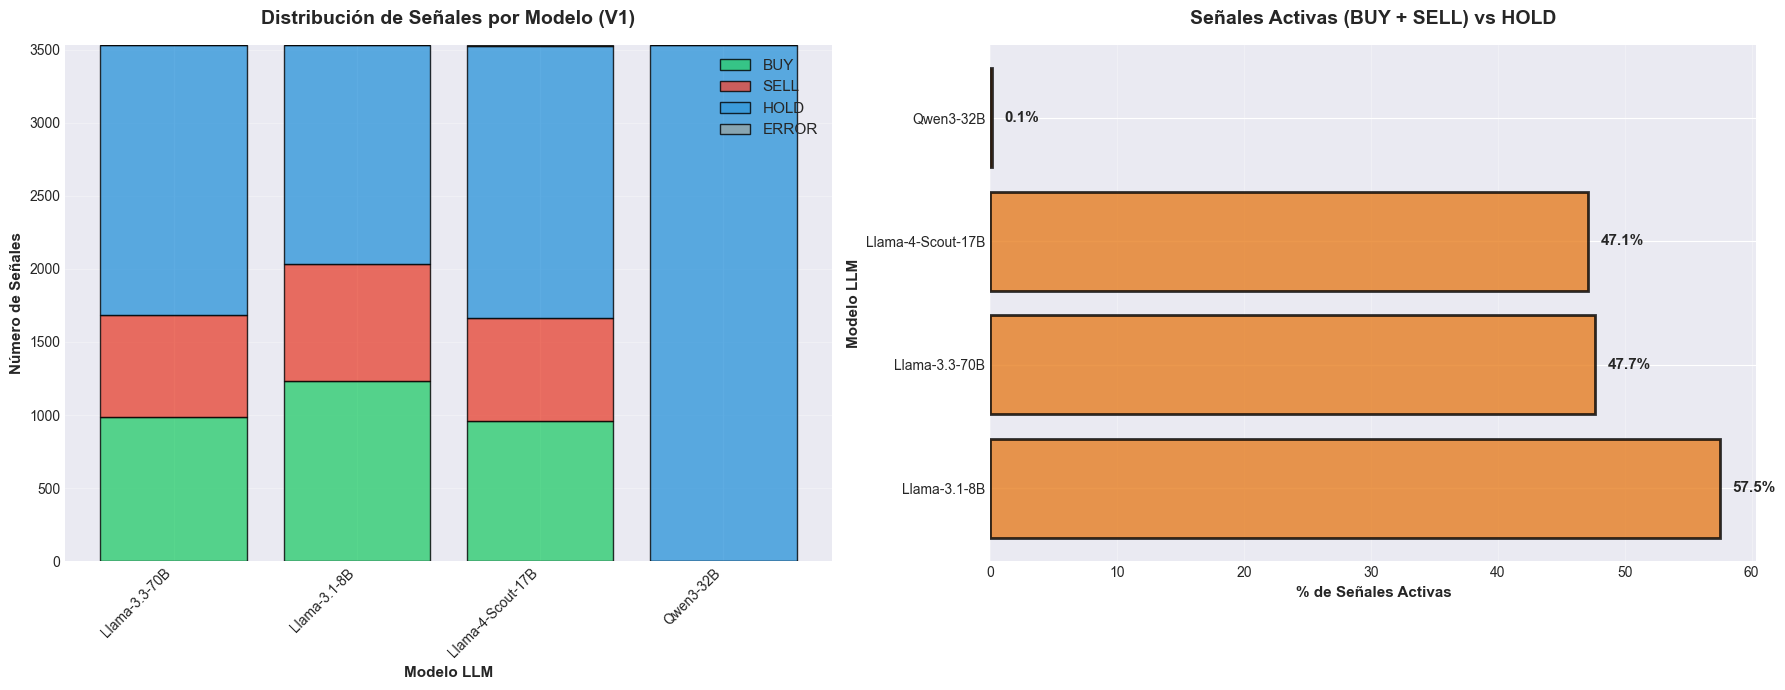

In [10]:
# Análisis detallado de señales por modelo
print("\n[ANÁLISIS] Distribución de Señales por Modelo")
print("="*80)

signal_analysis = []

for model in models:
    model_df = df[df['Model_Name'] == model]
    signals = model_df['Model_Signal'].value_counts()
    total = len(model_df)
    
    print(f"\n{model}:")
    print(f"  Total señales: {total}")
    
    signal_dict = {'Model': model, 'Total': total}
    
    for signal in ['BUY', 'SELL', 'HOLD', 'ERROR']:
        count = signals.get(signal, 0)
        pct = (count / total) * 100
        signal_dict[signal] = count
        signal_dict[f'{signal}_pct'] = pct
        
        if count > 0:
            print(f"    {signal}: {count} ({pct:.1f}%)")
    
    signal_analysis.append(signal_dict)

signal_df = pd.DataFrame(signal_analysis)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Stacked bar
signal_types = ['BUY', 'SELL', 'HOLD', 'ERROR']
colors_signal = {'BUY': '#2ecc71', 'SELL': '#e74c3c', 'HOLD': '#3498db', 'ERROR': '#95a5a6'}

bottom = np.zeros(len(signal_df))
for signal in signal_types:
    if signal in signal_df.columns:
        values = signal_df[signal].fillna(0)
        ax1.bar(signal_df['Model'], values, bottom=bottom, 
                label=signal, color=colors_signal[signal], alpha=0.8, edgecolor='black')
        bottom += values

ax1.set_title('Distribución de Señales por Modelo (V1)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Modelo LLM', fontsize=11, fontweight='bold')
ax1.set_ylabel('Número de Señales', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Gráfico 2: Porcentaje activo
signal_df['Active_Signals'] = signal_df['BUY'].fillna(0) + signal_df['SELL'].fillna(0)
signal_df['Active_pct'] = (signal_df['Active_Signals'] / signal_df['Total']) * 100

signal_df_sorted = signal_df.sort_values('Active_pct', ascending=False)

bars = ax2.barh(signal_df_sorted['Model'], signal_df_sorted['Active_pct'], 
                color='#e67e22', alpha=0.8, edgecolor='black', linewidth=2)

for bar, val in zip(bars, signal_df_sorted['Active_pct']):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2., 
             f'{val:.1f}%', 
             ha='left', va='center', fontweight='bold', fontsize=11)

ax2.set_title('Señales Activas (BUY + SELL) vs HOLD', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('% de Señales Activas', fontsize=11, fontweight='bold')
ax2.set_ylabel('Modelo LLM', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 9️⃣ Resumen Ejecutivo y Recomendaciones

In [11]:
print("="*80)
print("[RESUMEN EJECUTIVO] ANÁLISIS DE MODELOS V1")
print("="*80)

# Mejor modelo por ROI
best_model = max(finals, key=finals.get)
best_profit = finals[best_model]
best_roi = (best_profit / 10000) * 100

# Peor modelo
worst_model = min(finals, key=finals.get)
worst_profit = finals[worst_model]
worst_roi = (worst_profit / 10000) * 100

print(f"\n[1] RENTABILIDAD:")
print(f"  Mejor Modelo: {best_model}")
print(f"    - ROI: {best_roi:+.2f}%")
print(f"    - Beneficio: ${best_profit:+,.2f}")
print(f"\n  Peor Modelo: {worst_model}")
print(f"    - ROI: {worst_roi:+.2f}%")
print(f"    - Pérdida: ${worst_profit:+,.2f}")

if not price_df.empty:
    print(f"\n[2] MERCADO:")
    print(f"  Tipo: {market_type}")
    print(f"  Cambio: {price_change:+.2f}%")
    print(f"  Hold ROI: {hold_roi:+.2f}%")

if 'Agreement_Level' in df.columns:
    avg_agreement = df.groupby('Cycle').first()['Agreement_Level'].mean()
    print(f"\n[3] CONSENSO:")
    print(f"  Agreement Promedio: {avg_agreement:.1f}%")

print(f"\n[RECOMENDACIÓN]:")
print("="*80)

if best_roi > hold_roi and best_roi > 0:
    print(f"[OK] {best_model} SUPERÓ al mercado")
    print(f"    Usar este modelo en producción.")
    print(f"    Alpha: {best_roi - hold_roi:+.2f}pp")
elif best_roi > 0 and best_roi < hold_roi:
    print(f"[INFO] {best_model} tuvo ganancias pero NO superó Hold")
    print(f"    Considerar estrategia Buy & Hold.")
else:
    print(f"[WARN] Todos los modelos tuvieron pérdidas")
    if price_change < -2:
        print(f"    Causa: Mercado bajista ({price_change:.2f}%)")
    else:
        print(f"    Causa: Decisiones pobres de los modelos")

print(f"\n[COMPARACIÓN V1 vs V2]:")
print(f"  Para comparar sistemas, ejecuta: python compare_v1_v2.py")
print("="*80)

[RESUMEN EJECUTIVO] ANÁLISIS DE MODELOS V1

[1] RENTABILIDAD:
  Mejor Modelo: Qwen3-32B
    - ROI: +6.92%
    - Beneficio: $+692.05

  Peor Modelo: Llama-4-Scout-17B
    - ROI: -2.71%
    - Pérdida: $-270.52

[2] MERCADO:
  Tipo: LATERAL
  Cambio: -0.25%
  Hold ROI: -0.25%

[3] CONSENSO:
  Agreement Promedio: 82.0%

[RECOMENDACIÓN]:
[OK] Qwen3-32B SUPERÓ al mercado
    Usar este modelo en producción.
    Alpha: +7.17pp

[COMPARACIÓN V1 vs V2]:
  Para comparar sistemas, ejecuta: python compare_v1_v2.py
